In [122]:
import pandas as pd
import io
from google.colab import files
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from pylab import rcParams

In [ ]:
uploaded = files.upload()
file_name = list(uploaded.keys())[0]

In [132]:
df = pd.read_excel(file_name, header=None)

start_row = None
for idx, row in df.iterrows():
    if row[0] == 'Month':
        start_row = idx + 1
        break


df_clean = pd.read_excel(file_name, header=None, skiprows=start_row)
df_clean.columns = ['Month', 'Car_sales']

df_clean['Month'] = pd.to_datetime(df_clean['Month'])




print(f"\nФорма данных: {df_clean.shape}")
print(f"Период: с {df_clean['Month'].min()} по {df_clean['Month'].max()}")
print(f"Всего записей: {len(df_clean)}")

# Простой график
# plt.figure(figsize=(12, 6))
# plt.plot(df_clean['Month'], df_clean['Car_sales'], linewidth=1)
# plt.title('Продажи автомобилей в Квебеке (1960–1968)', fontsize=14)
# plt.xlabel('Количество проданных автомобилей', fontsize=12)
# plt.ylabel('Car Sales', fontsize=12)
# plt.grid(True, alpha=0.3)
# plt.xticks(rotation=45)
# plt.tight_layout()
# plt.show()


Форма данных: (108, 2)
Период: с 1960-01-01 00:00:00 по 1968-12-01 00:00:00
Всего записей: 108


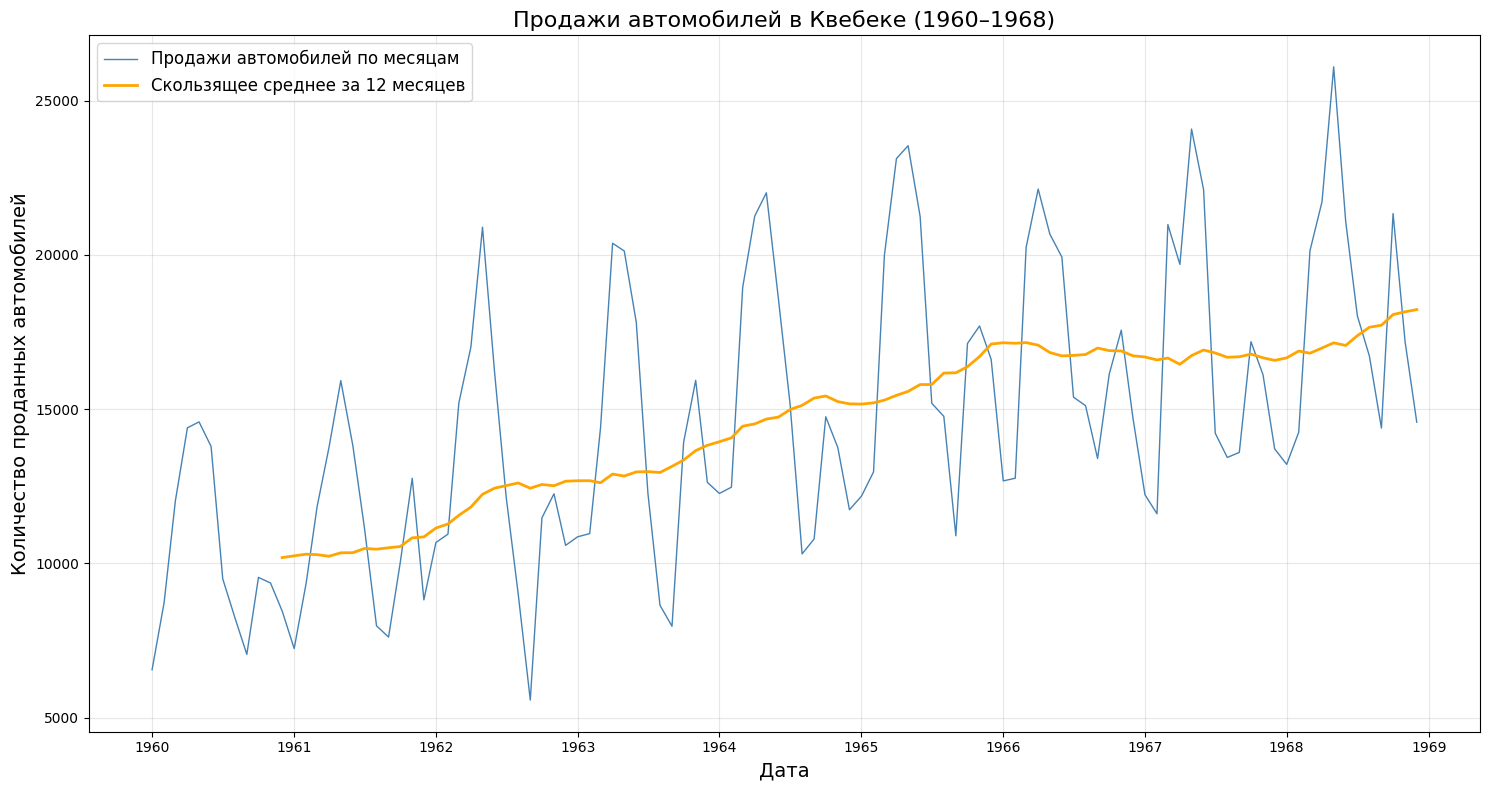

In [133]:
# @title Скользящее среднее (12 месяцев)

plt.figure(figsize=(15, 8))

plt.plot(df_clean['Month'], df_clean['Car_sales'],
         label='Продажи автомобилей по месяцам',
         color='steelblue', linewidth=1)

rolling_mean = df_clean['Car_sales'].rolling(window=12).mean()
plt.plot(df_clean['Month'], rolling_mean,
         label='Скользящее среднее за 12 месяцев',
         color='orange', linewidth=2)

plt.legend(title='', loc='upper left', fontsize=12)
plt.xlabel('Дата', fontsize=14)
plt.ylabel('Количество проданных автомобилей', fontsize=14)
plt.title('Продажи автомобилей в Квебеке (1960–1968)', fontsize=16)

plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

Индекс: DatetimeIndex(['1960-01-01', '1960-02-01', '1960-03-01', '1960-04-01',
               '1960-05-01'],
              dtype='datetime64[ns]', name='Month', freq=None)
Частота индекса: None


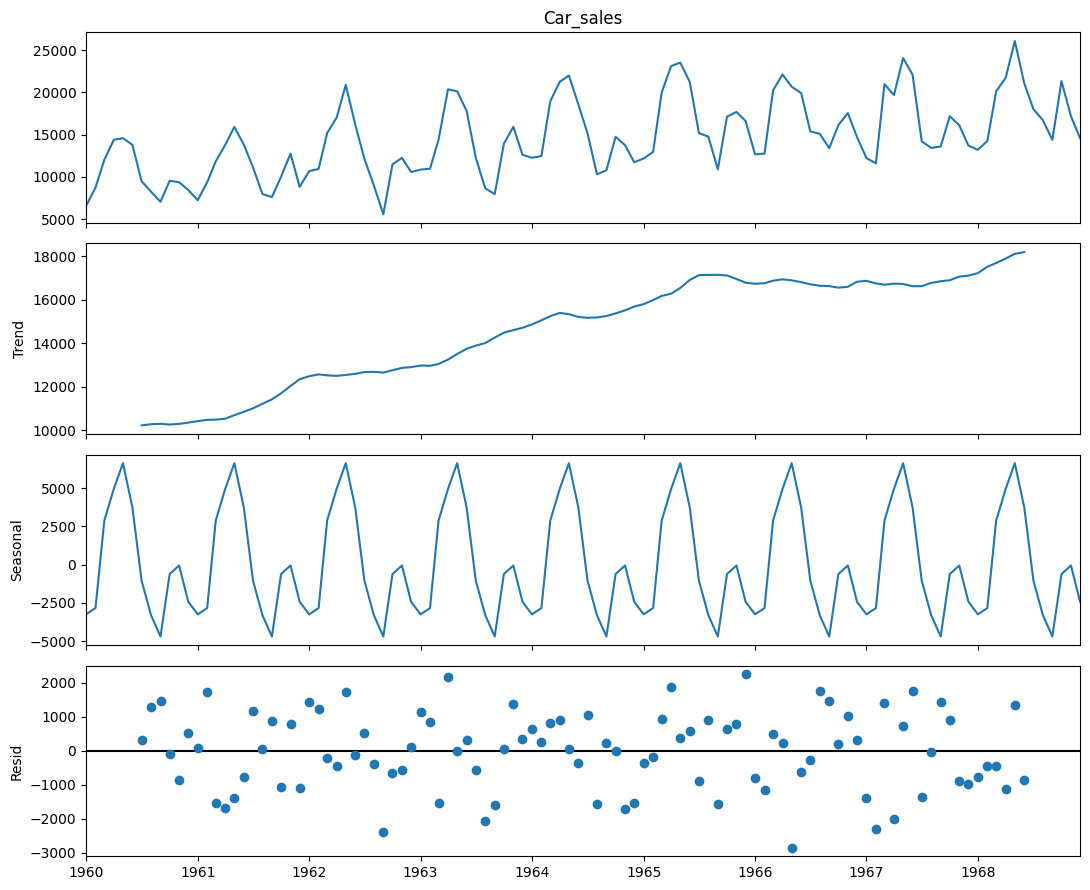

In [134]:
# @title Анализ комонент временного ряда

rcParams['figure.figsize'] = 11, 9

df_clean.set_index('Month', inplace=True)

print(f"Индекс: {df_clean.index[:5]}")
print(f"Частота индекса: {df_clean.index.freq}")

if df_clean.index.freq is None:
    df_clean = df_clean.asfreq('MS')  # MS = Month Start

decompose = seasonal_decompose(df_clean['Car_sales'], model='additive', period=12)
decompose.plot()

plt.show()

In [135]:
# @title Тест Дики-Фуллера (стационарность)

adf_test = adfuller(df_clean['Car_sales'])
print('p-value = ' + str(adf_test[1]))

# p-value = 0.6632691049832861 => ряд не стационарный

p-value = 0.6632691049832861


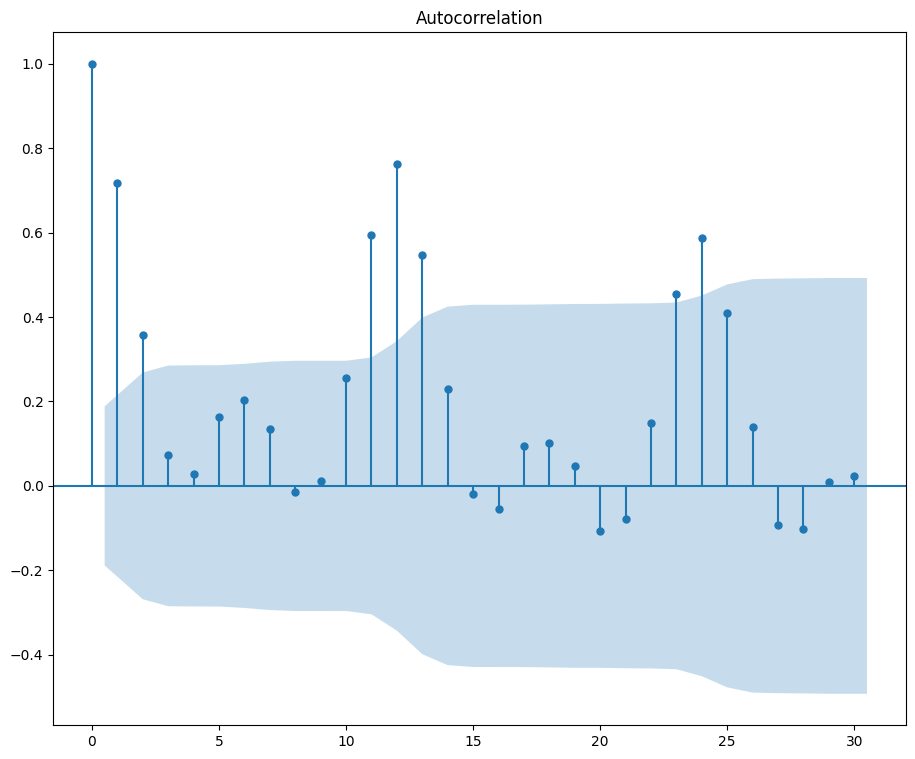

In [136]:
# @title Коррелограмма

plot_acf(df_clean, lags=30) # на 30 лагов вперед
plt.axis('tight')
plt.show()

# синяя граница позволяет оценить статистическую значимость корреляции. Если столбец выходит за ее пределы, то автокорреляция достаточно сильна и ее можно использовать при построении модели.

Автокорреляция первого порядка (лаг 1): 0.7281
Количество пар для расчёта: 107


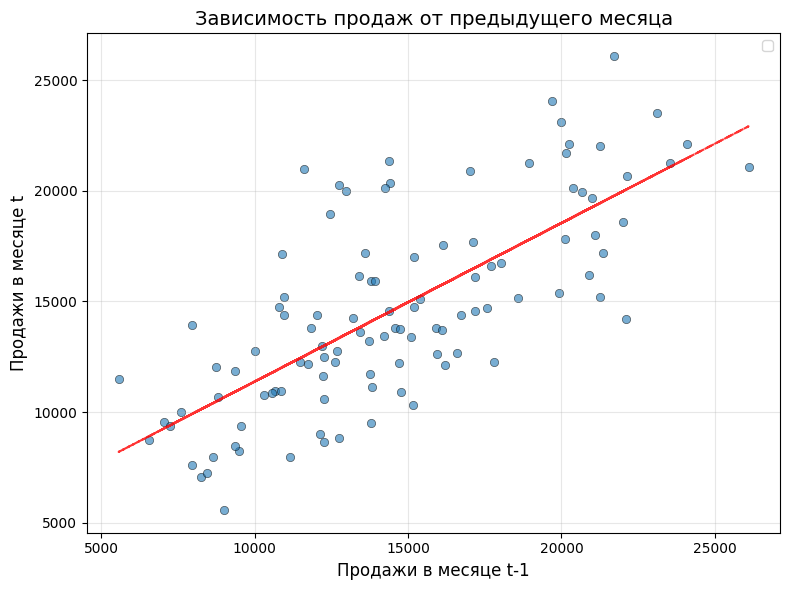

In [137]:
# @title Коэффициент автокорреляции первого порядка


if 'Month' in df_clean.columns and 'Car_sales' in df_clean.columns:
    df_clean.set_index('Month', inplace=True)
    df_clean = df_clean.asfreq('MS')

y = df_clean['Car_sales'].values


y_t = y[1:]      # значения с 1-го по последний
y_lag1 = y[:-1]  # значения с 0-го по предпоследний

# Расчёт автокорреляции первого порядка
autocorr_lag1 = np.corrcoef(y_t, y_lag1)[0, 1]

print(f"Автокорреляция первого порядка (лаг 1): {autocorr_lag1:.4f}")
print(f"Количество пар для расчёта: {len(y_t)}") # должно быть n - 1, то есть 107

plt.figure(figsize=(8, 6))
plt.scatter(y_lag1, y_t, alpha=0.6, edgecolors='black', linewidth=0.5)
plt.xlabel('Продажи в месяце t-1', fontsize=12)
plt.ylabel('Продажи в месяце t', fontsize=12)
plt.title(f'Зависимость продаж от предыдущего месяца', fontsize=14)
plt.grid(True, alpha=0.3)

z = np.polyfit(y_lag1, y_t, 1)
p = np.poly1d(z)
plt.plot(y_lag1, p(y_lag1), "r--", alpha=0.8)

plt.legend()
plt.tight_layout()
plt.show()

In [138]:
# @title Модель тройного экспоненциального сглаживания

import warnings
warnings.filterwarnings("ignore")


if not isinstance(df_clean.index, pd.DatetimeIndex) or df_clean.index.freq is None:
    if 'Month' in df_clean.columns:
        df_clean = df_clean.set_index('Month')
    df_clean = df_clean.asfreq('MS')

ts = df_clean['Car_sales']


# Аддитивная версия
model_add = ExponentialSmoothing(ts,
                                 trend='add',
                                 seasonal='add',
                                 seasonal_periods=12)

# Мультипликативная версия
model_mul = ExponentialSmoothing(ts,
                                 trend='mul',
                                 seasonal='mul',
                                 seasonal_periods=12)

fit_add = model_add.fit(optimized=True, use_brute=True)
fit_mul = model_mul.fit(optimized=True, use_brute=True)

print("AIC аддитивной модели: {:.2f}".format(fit_add.aic))
print("AIC мультипликативной модели: {:.2f}".format(fit_mul.aic))

if fit_add.aic < fit_mul.aic:
    best_fit = fit_add
    best_type = "Аддитивная"
else:
    best_fit = fit_mul
    best_type = "Мультипликативная"

print(f"\nЛучшая модель: {best_type} Holt-Winters")
print(best_fit.summary())


AIC аддитивной модели: 1585.75
AIC мультипликативной модели: 1588.17

Лучшая модель: Аддитивная Holt-Winters
                       ExponentialSmoothing Model Results                       
Dep. Variable:                Car_sales   No. Observations:                  108
Model:             ExponentialSmoothing   SSE                      191175644.359
Optimized:                         True   AIC                           1585.750
Trend:                         Additive   BIC                           1628.664
Seasonal:                      Additive   AICC                          1593.435
Seasonal Periods:                    12   Date:                 Mon, 20 Apr 2026
Box-Cox:                          False   Time:                         08:05:07
Box-Cox Coeff.:                    None                                         
                          coeff                 code              optimized      
--------------------------------------------------------------------------------


Прогноз продаж автомобилей в Квебеке:
            Прогноз
1969-01-01    15560
1969-02-01    16238
1969-03-01    21762


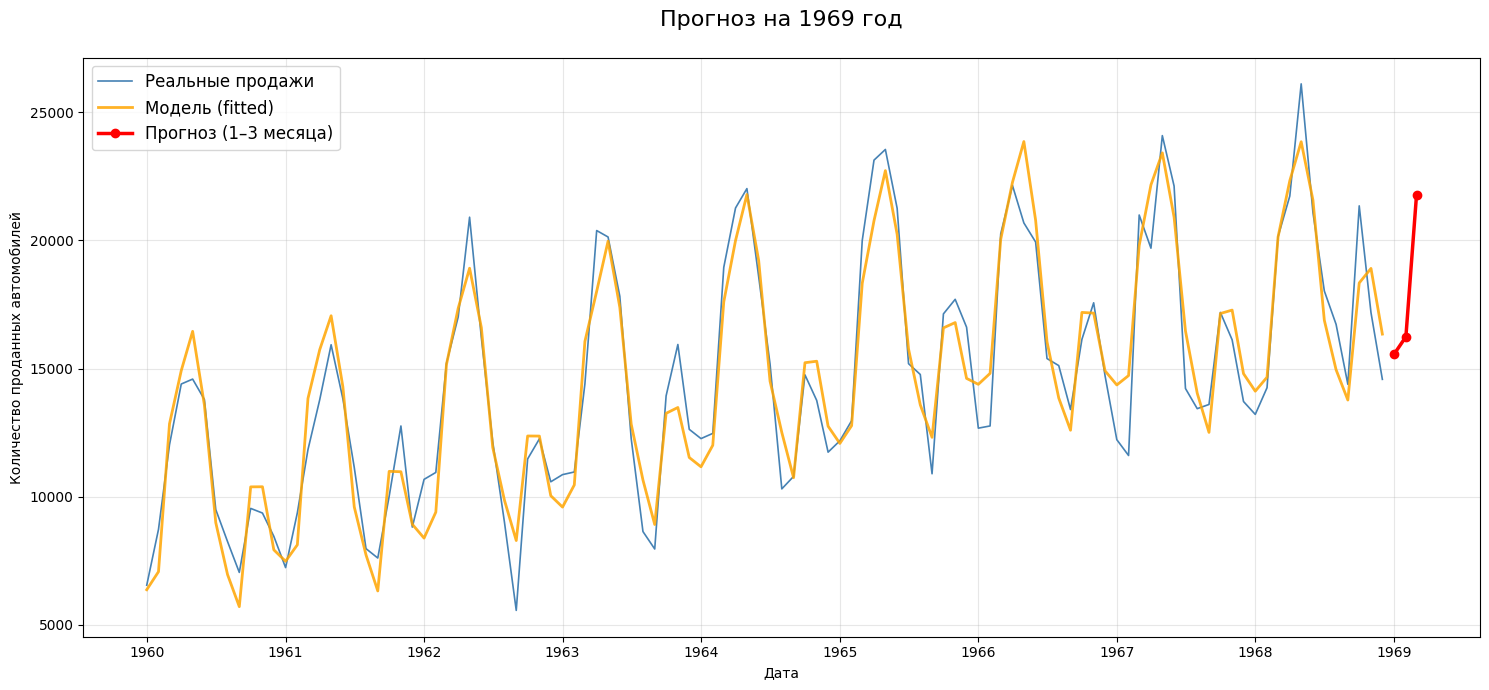

In [139]:
# @title Прогноз на 3 лага вперед

forecast_steps = 3
forecast = best_fit.forecast(steps=forecast_steps)

last_date = ts.index[-1]
future_dates = pd.date_range(start=last_date + pd.offsets.MonthBegin(1),
                             periods=forecast_steps,
                             freq='MS')

forecast_df = pd.DataFrame({
    'Прогноз': forecast.values.round(0).astype(int)
}, index=future_dates)

print("\nПрогноз продаж автомобилей в Квебеке:")
print(forecast_df)

plt.figure(figsize=(15, 7))

plt.plot(ts, label='Реальные продажи', color='steelblue', linewidth=1.2)

plt.plot(best_fit.fittedvalues, label='Модель (fitted)',
         color='orange', linewidth=2, alpha=0.85)

# Прогноз
plt.plot(forecast_df.index, forecast_df['Прогноз'],
         label='Прогноз (1–3 месяца)',
         color='red', marker='o', markersize=6, linewidth=2.5)

plt.title('Прогноз на 1969 год\n',
          fontsize=16)
plt.xlabel('Дата')
plt.ylabel('Количество проданных автомобилей')
plt.legend(fontsize=12)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()